In [31]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [32]:
df = pd.read_csv("dataset/star_classification.csv")

df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [33]:
df.shape

(240, 7)

In [34]:
df.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


In [35]:
df.isnull().sum()

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df = df.drop_duplicates()

In [38]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.2+ KB


In [40]:
df["Star type"].value_counts()

Star type
0    40
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64

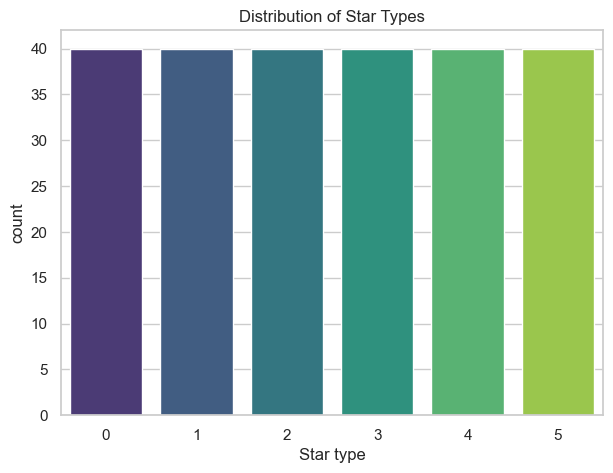

In [41]:
plt.figure(figsize=(7,5))
sns.countplot(x="Star type", data=df, palette="viridis")
plt.title("Distribution of Star Types")
plt.show()

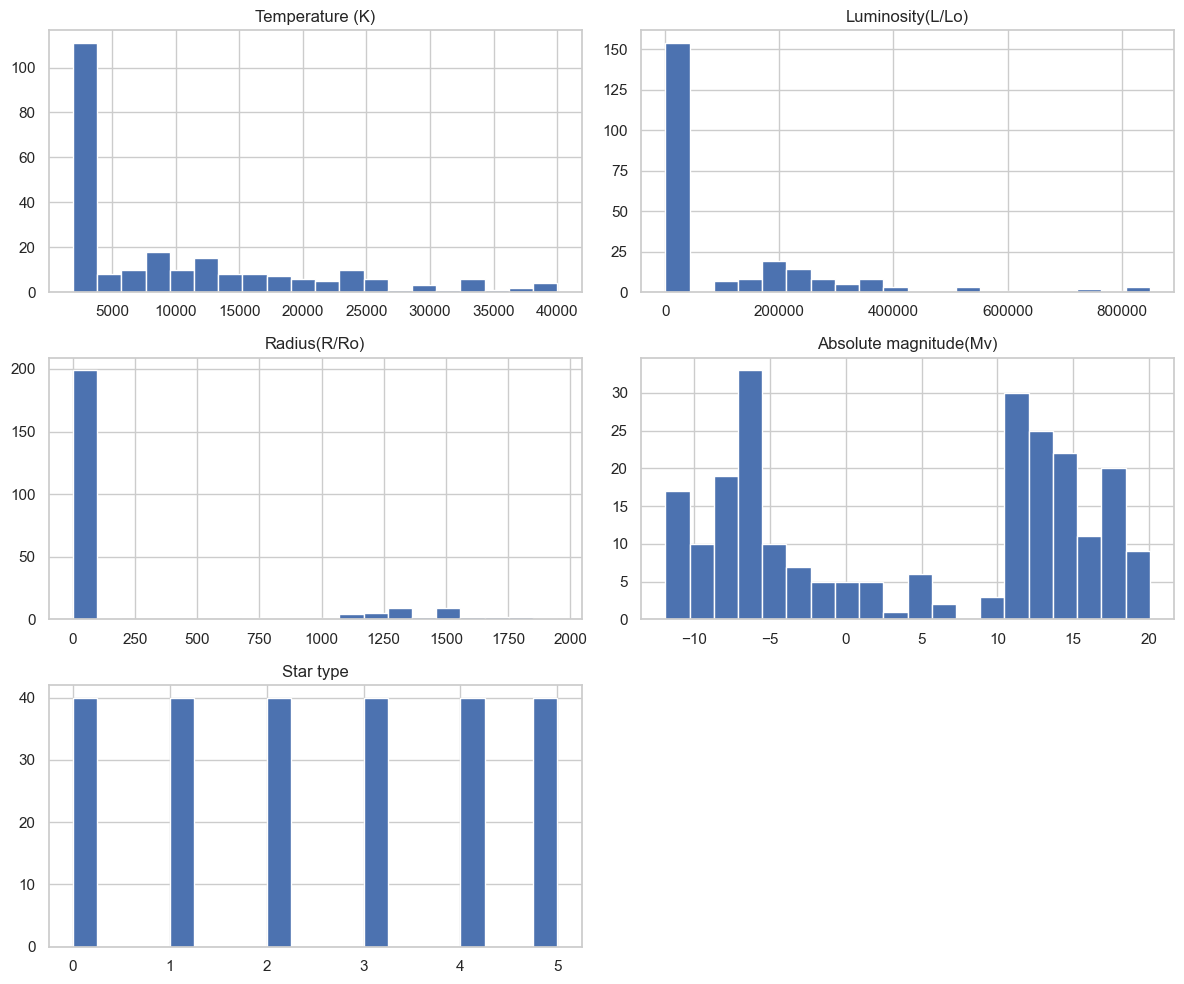

In [42]:
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

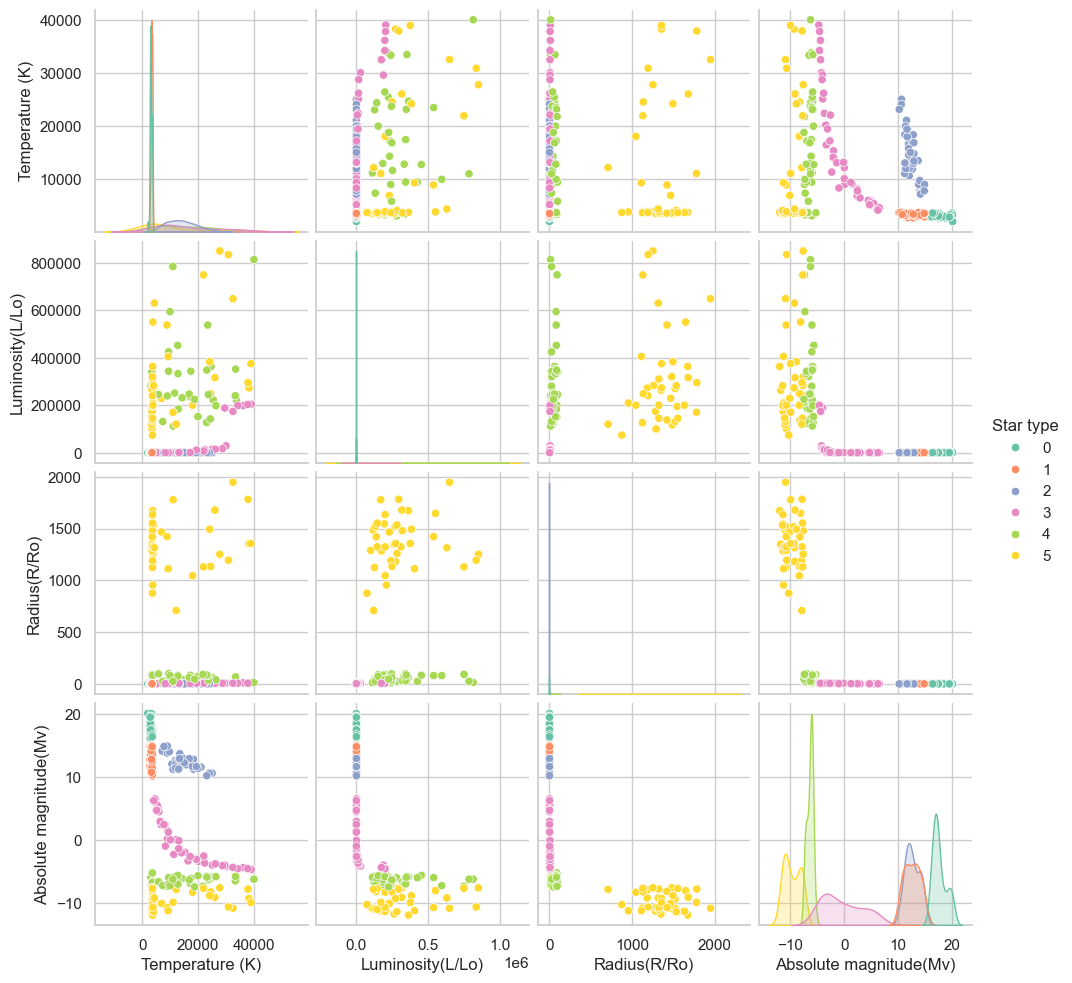

In [43]:
sns.pairplot(
    df,
    hue="Star type",
    palette="Set2"
)

plt.show()

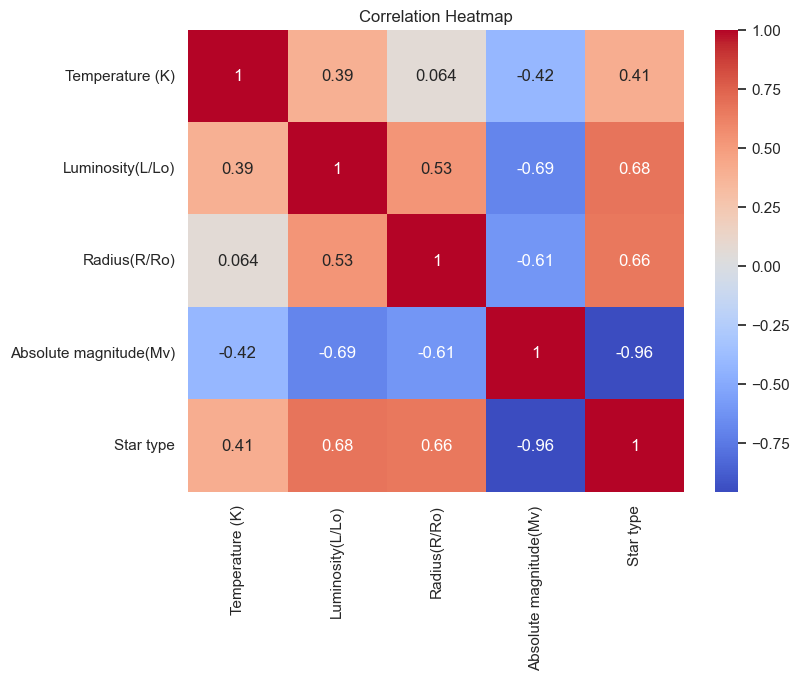

In [44]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [45]:
from sklearn.preprocessing import LabelEncoder

le_color = LabelEncoder()
le_spec = LabelEncoder()

df["Star color"] = le_color.fit_transform(df["Star color"])
df["Spectral Class"] = le_spec.fit_transform(df["Spectral Class"])

In [46]:
df.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,10,5
1,3042,0.000500,0.1542,16.60,0,10,5
2,2600,0.000300,0.1020,18.70,0,10,5
3,2800,0.000200,0.1600,16.65,0,10,5
4,1939,0.000138,0.1030,20.06,0,10,5


In [47]:
X = df.drop("Star type", axis=1)

y = df["Star type"]

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(192, 6)
(48, 6)
(192,)
(48,)


In [51]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [52]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [53]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

In [54]:
svm = SVC(kernel="rbf")

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

In [55]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [56]:
def evaluate_model(model_name, y_true, y_pred):

    print("="*60)
    print(model_name)
    print("="*60)

    print(f"Accuracy : {accuracy_score(y_true,y_pred):.4f}")
    print(f"Precision: {precision_score(y_true,y_pred,average='weighted'):.4f}")
    print(f"Recall   : {recall_score(y_true,y_pred,average='weighted'):.4f}")
    print(f"F1 Score : {f1_score(y_true,y_pred,average='weighted'):.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true,y_pred))

    plt.figure(figsize=(6,5))

    sns.heatmap(
        confusion_matrix(y_true,y_pred),
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

Logistic Regression
Accuracy : 0.9167
Precision: 0.9250
Recall   : 0.9167
F1 Score : 0.9160

Classification Report

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       1.00      0.75      0.86         8
           2       1.00      1.00      1.00         8
           3       0.88      0.88      0.88         8
           4       0.88      0.88      0.88         8
           5       1.00      1.00      1.00         8

    accuracy                           0.92        48
   macro avg       0.92      0.92      0.92        48
weighted avg       0.92      0.92      0.92        48



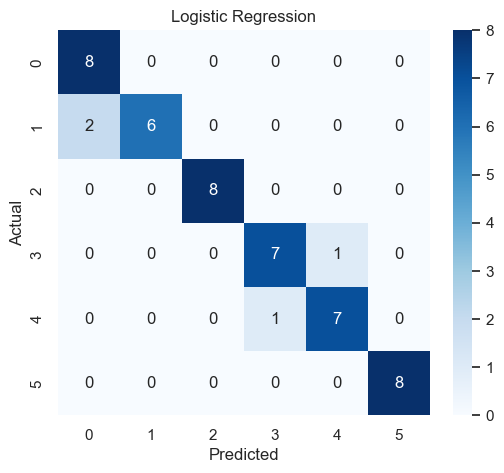

Decision Tree
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



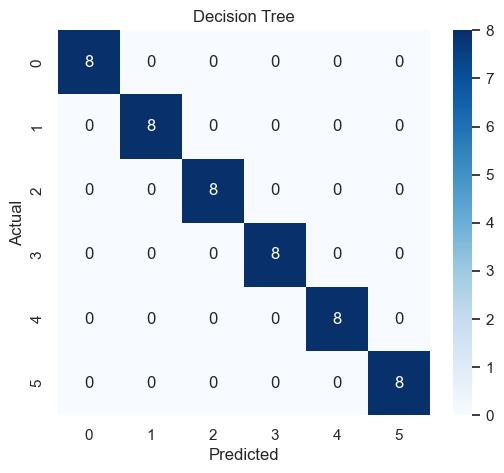

Random Forest
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         8

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



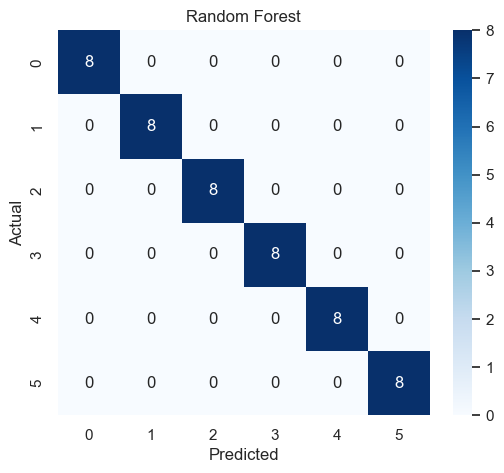

KNN
Accuracy : 0.9167
Precision: 0.9206
Recall   : 0.9167
F1 Score : 0.9163

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.89      1.00      0.94         8
           2       1.00      1.00      1.00         8
           3       0.78      0.88      0.82         8
           4       0.86      0.75      0.80         8
           5       1.00      0.88      0.93         8

    accuracy                           0.92        48
   macro avg       0.92      0.92      0.92        48
weighted avg       0.92      0.92      0.92        48



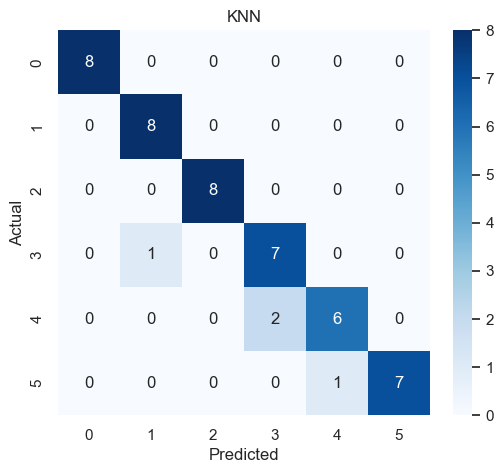

SVM
Accuracy : 0.9375
Precision: 0.9481
Recall   : 0.9375
F1 Score : 0.9368

Classification Report

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       1.00      0.75      0.86         8
           2       1.00      1.00      1.00         8
           3       0.89      1.00      0.94         8
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00         8

    accuracy                           0.94        48
   macro avg       0.95      0.94      0.94        48
weighted avg       0.95      0.94      0.94        48



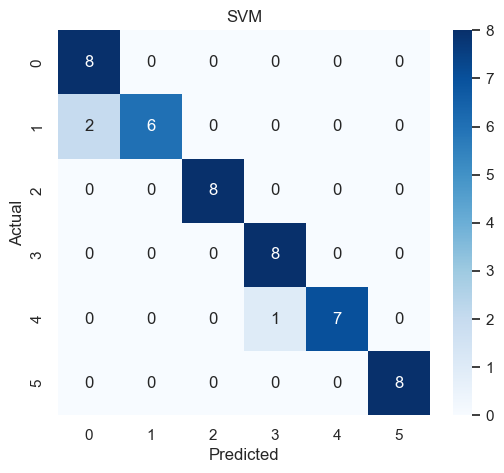

In [57]:
evaluate_model("Logistic Regression", y_test, pred_lr)

evaluate_model("Decision Tree", y_test, pred_dt)

evaluate_model("Random Forest", y_test, pred_rf)

evaluate_model("KNN", y_test, pred_knn)

evaluate_model("SVM", y_test, pred_svm)

In [58]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_knn),
        accuracy_score(y_test,pred_svm)
    ],
    "Precision":[
        precision_score(y_test,pred_lr,average="weighted"),
        precision_score(y_test,pred_dt,average="weighted"),
        precision_score(y_test,pred_rf,average="weighted"),
        precision_score(y_test,pred_knn,average="weighted"),
        precision_score(y_test,pred_svm,average="weighted")
    ],
    "Recall":[
        recall_score(y_test,pred_lr,average="weighted"),
        recall_score(y_test,pred_dt,average="weighted"),
        recall_score(y_test,pred_rf,average="weighted"),
        recall_score(y_test,pred_knn,average="weighted"),
        recall_score(y_test,pred_svm,average="weighted")
    ],
    "F1 Score":[
        f1_score(y_test,pred_lr,average="weighted"),
        f1_score(y_test,pred_dt,average="weighted"),
        f1_score(y_test,pred_rf,average="weighted"),
        f1_score(y_test,pred_knn,average="weighted"),
        f1_score(y_test,pred_svm,average="weighted")
    ]
})

results.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000
4,SVM,0.937500,0.948148,0.937500,0.936757
0,Logistic Regression,0.916667,0.925000,0.916667,0.916005
3,KNN,0.916667,0.920635,0.916667,0.916340


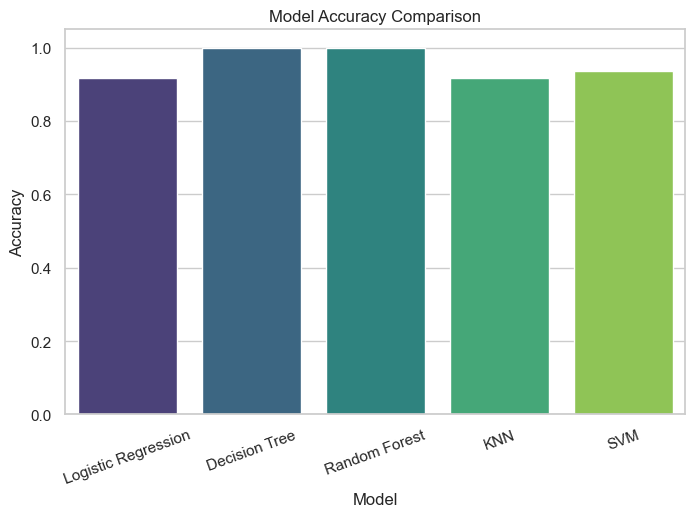

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=20)
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1.05)

plt.show()

In [60]:
feature_names = df.drop("Star type", axis=1).columns

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
3,Absolute magnitude(Mv),0.351451
2,Radius(R/Ro),0.302362
1,Luminosity(L/Lo),0.154534
5,Spectral Class,0.085945
0,Temperature (K),0.085255
4,Star color,0.020453


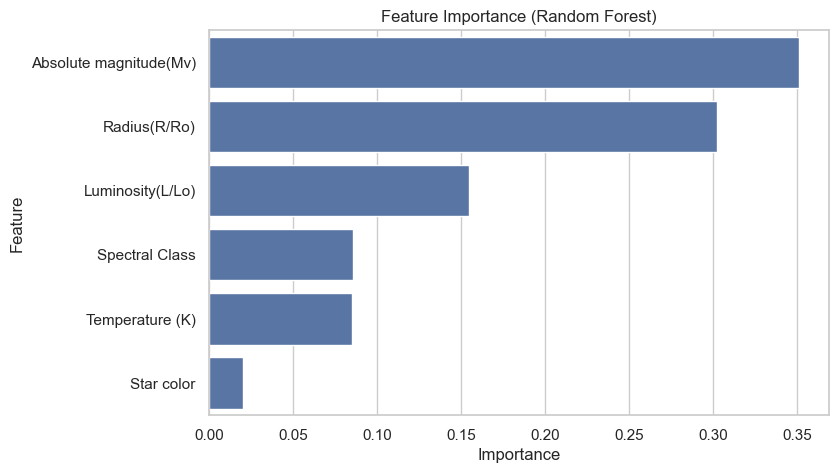

In [61]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")
plt.show()

In [62]:
import joblib

joblib.dump(rf, "star_classifier.pkl")

['star_classifier.pkl']

In [63]:
sample = X_test[0].reshape(1, -1)

prediction = rf.predict(sample)

print("Predicted Star Type:", prediction[0])
print("Actual Star Type:", y_test.iloc[0])

Predicted Star Type: 1
Actual Star Type: 1


## Conclusion

- Loaded and explored the Star Classification dataset.
- Performed preprocessing, encoding, and feature scaling.
- Trained five supervised machine learning models.
- Compared their performance using Accuracy, Precision, Recall, and F1-score.
- Decision Tree and Random Forest achieved the highest accuracy of 100% on the test set.
- Random Forest was selected as the best-performing model for this dataset.